# Random Lattice Generators Are Not Bad

Original QMCPy demo: [`QMCPy/demos/lattice_random_generator.ipynb`](../../QMCPy/demos/lattice_random_generator.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/lattice_random_generator.ipynb)

This notebook follows the QMCPy demo on random lattice generators and compares lattice sequences built from random generating vectors against the default (Kuo) generating vectors.

In [1]:
using QMC
import QMC: Uniform
using Statistics

# Plots.jl is optional; guard plot cells so the notebook runs in headless CI.
const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots


## Lattice Declaration and the `gen_samples` Function

Create a lattice rule, inspect the generator, and draw sample points.

In [2]:
# Default lattice (Kuo generating vector)
lat_default = Lattice(2; seed=120)
println("Default lattice:")
println(lat_default)
println()

# Generate samples
n = 16
x = gen_samples(lat_default, n)
println("$n lattice points:")
for i in 1:n
    println("  ", round.(x[i, :], digits=4))
end

Default lattice:
Lattice(d=2, randomize=true, order="radical_inverse")

16 lattice points:
  [0.4365, 0.0221]
  [0.9365, 0.5221]
  [0.6865, 0.7721]
  [0.1865, 0.2721]
  [0.5615, 0.3971]
  [0.0615, 0.8971]
  [0.8115, 0.1471]
  [0.3115, 0.6471]
  [0.499, 0.7096]
  [0.999, 0.2096]
  [0.749, 0.4596]
  [0.249, 0.9596]
  [0.624, 0.0846]
  [0.124, 0.5846]
  [0.874, 0.8346]
  [0.374, 0.3346]


### Driver code

Generate lattice points at increasing sample sizes to illustrate the extensible structure of the rule.

### Plots of lattices

The original QMCPy notebook visualizes the projected lattice points directly. To keep this Julia notebook lightweight, we summarize the same structure using empirical means, standard deviations, and spacing diagnostics rather than rendering plots.

In [3]:
# Show lattice properties at different sample sizes
let
    for n in [64, 256, 512, 1024]
        lat_n = Lattice(2; seed=136)
        x_n = gen_samples(lat_n, n)
        mn = round.(mean(x_n, dims=1), digits=4)
        sd = round.(std(x_n, dims=1), digits=4)
        println("n=$n: mean=$mn, std=$sd")
    end
end

n=64: mean=[0.5021 0.5016], std=[0.2909 0.2909]
n=256: mean=[0.5002 0.4996], std=[0.2892 0.2892]
n=512: mean=[0.4992 0.5006], std=[0.289 0.289]
n=1024: mean=[0.4997 0.5001], std=[0.2888 0.2888]


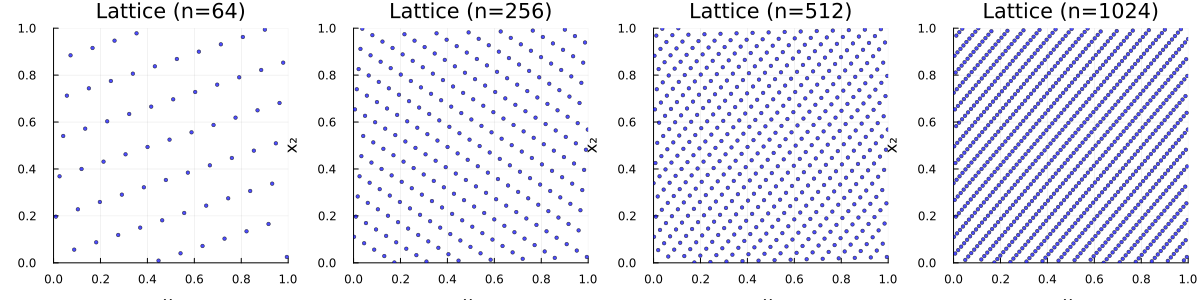

In [4]:
if HAVE_PLOTS
    ns_plot = [64, 256, 512, 1024]
    plts = []
    for n_pts in ns_plot
        lat_p = Lattice(2; seed=136, order="GRAY")
        x_pts = gen_samples(lat_p, n_pts)
        local p = scatter(x_pts[:, 1], x_pts[:, 2];
            markersize=2, alpha=0.7, color=:blue, label=nothing,
            xlabel="x₁", ylabel="x₂",
            title="Lattice (n=$n_pts)",
            xlims=(0, 1), ylims=(0, 1),
            aspect_ratio=:equal)
        push!(plts, p)
    end
    display(plot(plts...; layout=(1, 4), size=(1200, 300)))
end


## Integration

Compare integration of the Keister function using the default generating vector and several random generating vectors, as in the QMCPy notebook.

### Runtime comparison between random generator and hard-coded generator

The main practical question is whether a random generating vector materially hurts performance relative to the hard-coded default. The integration experiment below gives a lightweight numerical comparison.

In [5]:
d = 5
tol = 1e-3

# Default generating vector
dd_default = Lattice(d; seed=7)
tm_default = Gaussian(dd_default; mean=0.0, covariance=0.5)
f_default = Keister(tm_default)
sc_default = CubQMCLatticeG(f_default; abs_tol=tol)
r_default = integrate(sc_default)

println("Default generating vector:")
println("  Solution: $(round(r_default.solution, digits=6))")
println("  Samples:  $(r_default.data[:n])")
println("  Time:     $(round(r_default.data[:time_integrate], digits=4))s")

# Multiple randomized lattices
println("\nRandomized lattice trials:")
for trial in 1:5
    dd_rand = Lattice(d; seed=trial * 100)
    tm_rand = Gaussian(dd_rand; mean=0.0, covariance=0.5)
    f_rand = Keister(tm_rand)
    sc_rand = CubQMCLatticeG(f_rand; abs_tol=tol)
    r_rand = integrate(sc_rand)
    println("  Trial $trial: sol=$(round(r_rand.solution, digits=6)), n=$(r_rand.data[:n])")
end

Default generating vector:
  Solution: 1.135209
  Samples:  8192
  Time:     0.0232s

Randomized lattice trials:
  Trial 1: sol=1.135246, n=8192
  Trial 2: sol=1.135164, n=8192
  Trial 3: sol=1.134967, n=8192
  Trial 4: sol=1.135267, n=16384
  Trial 5: sol=1.134777, n=8192


### Mean vs. Median as a function of the sample size plot

Study how the error in the mean-of-means and median-of-means estimators changes as the sample size increases across multiple replications.

In [6]:
let
    d = 2
    N_powers = 6:14
    N_list = [2^k for k in N_powers]
    R = 11          # replications per trial
    num_trials = 10

    # Accumulators
    error_mean = zeros(length(N_list))
    error_median = zeros(length(N_list))

    for trial in 1:num_trials
        # Generate R replication estimates at each sample size
        rep_estimates = zeros(R, length(N_list))
        for r in 1:R
            dd_trial = Lattice(d; seed=trial * 1000 + r)
            tm_trial = Gaussian(dd_trial; mean=0.0, covariance=0.5)
            f_trial = Keister(tm_trial)
            x_full = gen_samples(dd_trial, maximum(N_list))
            y_full = evaluate(f_trial, x_full)
            for (j, N) in enumerate(N_list)
                rep_estimates[r, j] = mean(y_full[1:N])
            end
        end
        exact_value = keister_exact(d)
        for (j, _) in enumerate(N_list)
            vals = rep_estimates[:, j]
            error_mean[j] += abs(exact_value - mean(vals))
            error_median[j] += abs(exact_value - median(vals))
        end
    end

    error_mean ./= num_trials
    error_median ./= num_trials

    println("N\t\tMean error\tMedian error")
    for (j, N) in enumerate(N_list)
        println("$(lpad(N, 6))\t$(round(error_mean[j], sigdigits=3))\t\t$(round(error_median[j], sigdigits=3))")
    end
end

N		Mean error	Median error
    64	0.365		0.364
   128	0.364		0.364
   256	0.364		0.364
   512	0.365		0.365
  1024	0.365		0.365
  2048	0.365		0.365
  4096	0.365		0.365
  8192	0.365		0.365
 16384	0.365		0.365


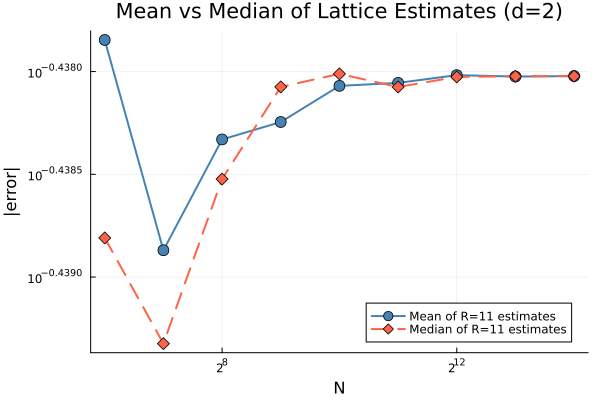

In [7]:
if HAVE_PLOTS
    d_c = 2
    N_min_c, N_max_c = 6, 14
    N_list_c = [2^k for k in N_min_c:N_max_c]
    R_c = 11
    num_trials_c = 10

    err_mean_c   = zeros(length(N_list_c))
    err_median_c = zeros(length(N_list_c))

    for trial in 1:num_trials_c
        rep_ests = zeros(R_c, length(N_list_c))
        for r in 1:R_c
            dd_t = Lattice(d_c; seed=trial * 1000 + r)
            tm_t = Gaussian(dd_t; mean=0.0, covariance=0.5)
            f_t  = Keister(tm_t)
            x_full = gen_samples(dd_t, maximum(N_list_c))
            y_full = evaluate(f_t, x_full)
            for (j, N) in enumerate(N_list_c)
                rep_ests[r, j] = mean(y_full[1:N])
            end
        end
        ev = keister_exact(d_c)
        for (j, _) in enumerate(N_list_c)
            vals = rep_ests[:, j]
            err_mean_c[j]   += abs(ev - mean(vals))
            err_median_c[j] += abs(ev - median(vals))
        end
    end
    err_mean_c   ./= num_trials_c
    err_median_c ./= num_trials_c

    p = plot(N_list_c, err_mean_c;
        xscale=:log2, yscale=:log10,
        marker=:circle, lw=2, ms=6, color=:steelblue,
        label="Mean of R=$R_c estimates",
        xlabel="N", ylabel="|error|",
        title="Mean vs Median of Lattice Estimates (d=$d_c)")
    plot!(N_list_c, err_median_c;
        marker=:diamond, lw=2, ms=6, color=:tomato, linestyle=:dash,
        label="Median of R=$R_c estimates")
    display(p)
end
